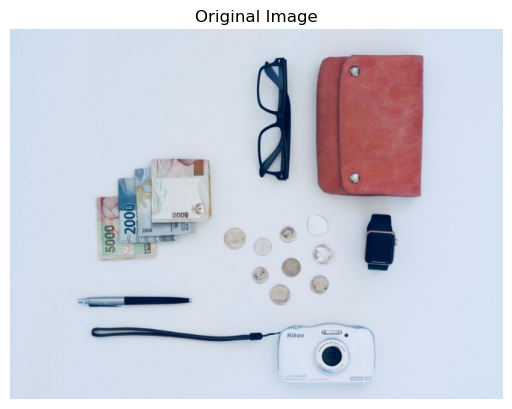

In [11]:
# Loading the image
import cv2
import numpy as np
import matplotlib.pyplot as plt
image = cv2.imread('objects1.jpg')
if image is None:
    print("Error: Image not found")
else:
    image = cv2.resize(image, (800, 600))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")
    plt.show()

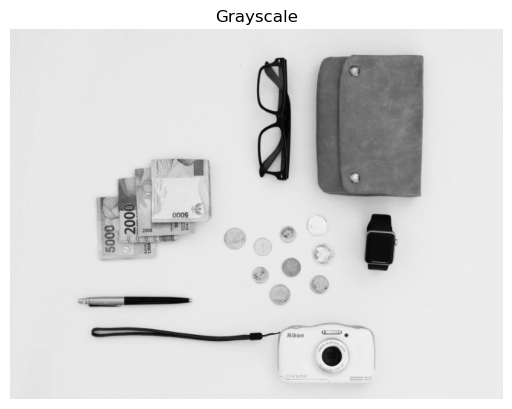

In [12]:
#Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")
plt.show()

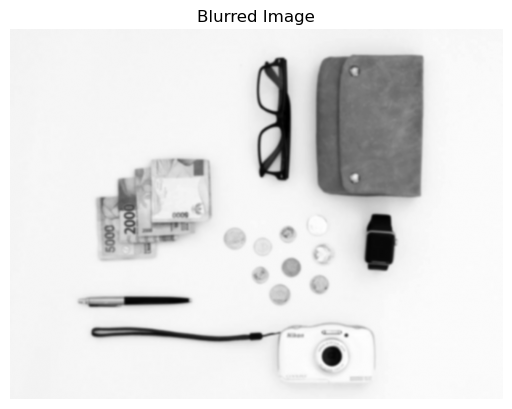

In [13]:
# blur
blur = cv2.GaussianBlur(gray, (7, 7), 0)

plt.imshow(blur, cmap='gray')
plt.title("Blurred Image")
plt.axis("off")
plt.show()

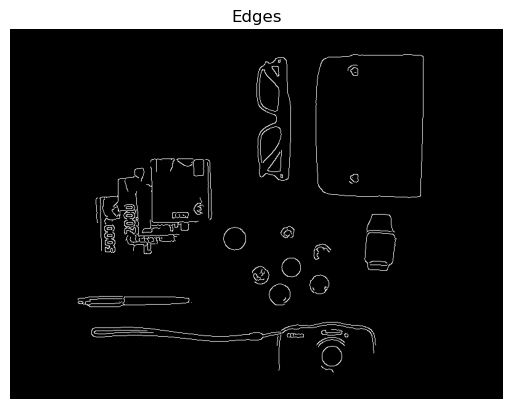

In [14]:
# Edge detection
edges = cv2.Canny(blur, 50, 100)

plt.imshow(edges, cmap='gray')
plt.title("Edges")
plt.axis("off")
plt.show()

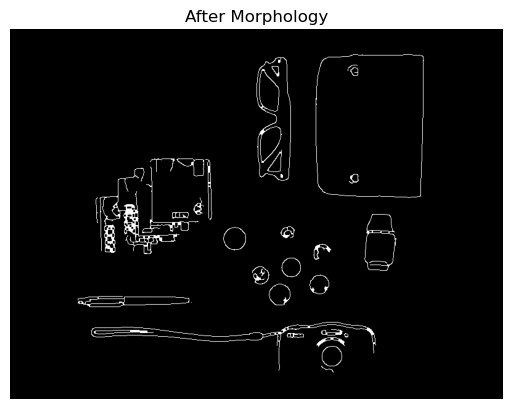

In [15]:
# Morphology
dilated = cv2.dilate(edges, None, iterations=1)
eroded = cv2.erode(dilated, None, iterations=1)

plt.imshow(eroded, cmap='gray')
plt.title("After Morphology")
plt.axis("off")
plt.show()

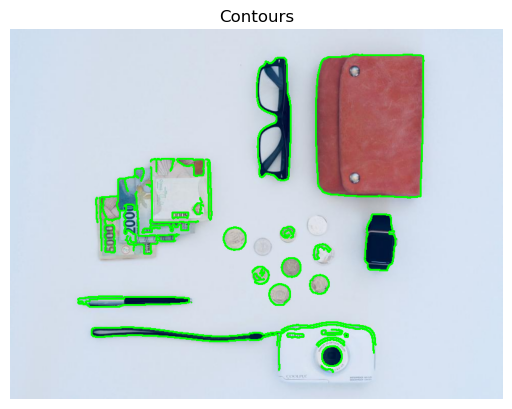

In [16]:
# contours
contours, _ = cv2.findContours(eroded.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contour_img = image.copy()
cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
plt.title("Contours")
plt.axis("off")
plt.show()

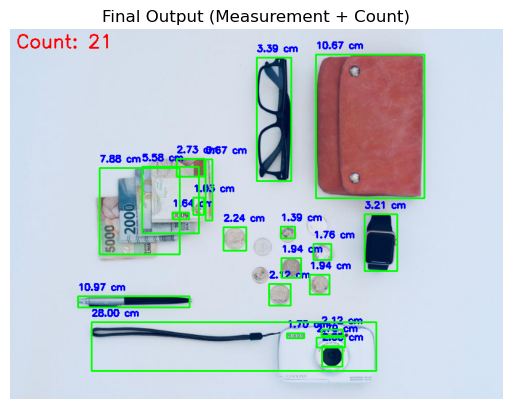

In [17]:
final_img = image.copy()
pixels_per_metric = None
count = 0

for c in contours:
    if cv2.contourArea(c) < 100:
        continue

    count += 1

    x, y, w, h = cv2.boundingRect(c)
    cv2.rectangle(final_img, (x, y), (x+w, y+h), (0, 255, 0), 2)

    # First object = reference (assume 2 cm)
    if pixels_per_metric is None:
        pixels_per_metric = w / 2.0

    dimension = w / pixels_per_metric

    cv2.putText(final_img, f"{dimension:.2f} cm",
                (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (255, 0, 0), 2)

cv2.putText(final_img, f"Count: {count}",
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            1, (0, 0, 255), 2)

plt.imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
plt.title("Final Output (Measurement + Count)")
plt.axis("off")
plt.show()